# Overview

**Image-to-Text Fusion - V1 (Base)**

This notebook implements the Image-to-Text Fusion pipeline for the Fake News Detection project.  
It combines AI-generated image captions with human-provided text to determine whether a news item is real or fake.

The goal of this notebook is to:
- Explore a fusion approach using a pretrained language model on human text and AI-generated image descriptions
- Use semantic similarity between the human-provided and AI-generated texts (via pretrained Sentence Transformers) as an additional alignment signal
- Add an LLM reasoning layer to evaluate whether multi-step inference improves decisions  

This pipeline has two levels of prediction:

1. RoBERTa Classifier  
`roberta-base-openai-detector` classifies both the human provided text and `Salesforce/blip-image-captioning-base` generated caption independently, and for each, outputs:
    - `fake` or `real`
    - confidence score (softmax probability)

2. LLM Reasoning Layer  
`gpt-4.1-mini` takes the RoBERTa outputs + human text and BLIP caption, and semantic similarity score from `all-mpnet-base-v2`, and returns:
    - Decision (Fake / Real)  
    - Short explanation  
    - Nudge (user-facing actionable advice)


**What This Notebook Covers**

- Load the Fakeddit metadata (clean headlines + image URLs)
- Generate captions using BLIP
- Classify both human texts and BLIP captions using RoBERTa
- Compute semantic similarity between text and caption using MPNet
- Fuse all signals using GPT-4.1-mini for reasoning
- Evaluate performance

> This notebook serves as a fusion baseline before building the full multimodal agentic system.


# Setup (Dependencies & Imports)

Install dependencies, clone the repo, and import required libraries and modules.

In [ ]:
# Install dependencies
!pip install -q transformers torch openai pillow torch scikit-learn sentence-transformers matplotlib seaborn

In [ ]:
# Clone the project repo
!git clone https://github.com/gizayceylan/FakeNews.git

# Add it to Python path
import sys
sys.path.append("/content/FakeNews")


Cloning into 'FakeNews'...
remote: Enumerating objects: 260, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 260 (delta 46), reused 30 (delta 14), pack-reused 171 (from 1)
Receiving objects: 100% (260/260), 19.61 MiB | 17.51 MiB/s, done.
Resolving deltas: 100% (134/134), done.


In [ ]:
# Imports
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import torch
import torch.nn.functional as F
import time
import subprocess
import json

from tqdm import tqdm
from PIL import Image

# ML/DL Libraries
from transformers import BlipProcessor, BlipForConditionalGeneration
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics import confusion_matrix, classification_report

# Import custom utility for OpenAI Client
from utils.api_key import load_openai_client


In [ ]:
# Set OpenAI API
client = load_openai_client()

# Metadata (Dataset Loading & Preparation)

Load the Fakeddit metadata, clean it, and select the subset of samples containing valid image URLs.

In [ ]:
# Unzip fakeddit_images.zip from /content/FakeNews/assets/content/master_pipeline_assets/
!unzip -q /content/FakeNews/assets/fakeddit_images.zip -d /content/FakeNews/assets

In [ ]:
# Load the pre-processed metadata
subset_path = "/content/FakeNews/assets/fakeddit_balanced_subset.csv"
image_df = pd.read_csv(subset_path)

# Define the path for the image directory (which was unzipped)
img_dir = "/content/FakeNews/assets/content/fakeddit_images"

# Update the DataFrame paths to reflect the new location
image_df['image_path'] = image_df['image_path'].apply(
    lambda p: os.path.join(img_dir, os.path.basename(p))
)

print(f"Loaded {len(image_df)} clean samples.")
print("Shape subset:", image_df.shape)
print(image_df["label"].value_counts())
image_df.head()


Loaded 150 clean samples.
Shape subset: (150, 5)
label
0    75
1    75
Name: count, dtype: int64


,image_path,clean_title,label,image_url,blip2_caption
0,/content/FakeNews/assets/content/fakeddit_imag...,bernie sander announces his campaign for presi...,0,https://preview.redd.it/m0yhjb563ek21.jpg?widt...,"yoda is sitting in a chair with the caption, ""..."
1,/content/FakeNews/assets/content/fakeddit_imag...,my dom nsfw,0,https://external-preview.redd.it/N5dbbbo3nx7uw...,a woman is standing in front of microphones
2,/content/FakeNews/assets/content/fakeddit_imag...,my inlaws moved into a building that hasnt upd...,1,https://preview.redd.it/knd5hhyozny21.jpg?widt...,a room with purple walls and green furniture
3,/content/FakeNews/assets/content/fakeddit_imag...,a leaf fell perfectly in the wet cement,1,https://preview.redd.it/70y4l9yhcsc31.jpg?widt...,a leaf on the sidewalk
4,/content/FakeNews/assets/content/fakeddit_imag...,a philadelphia bar cut a hall of famers baseba...,1,https://preview.redd.it/0ksailoiupe31.jpg?widt...,a baseball card with a picture of a man on it


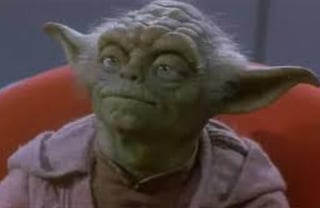

In [ ]:
# Test a sample
Image.open(image_df["image_path"].iloc[0])


In [ ]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Log GPU specs (model, driver, VRAM)
try:
    smi = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name,driver_version,memory.total", "--format=csv,noheader"],
        text=True
    ).strip()
    gpu_name, driver_version, vram_total = [x.strip() for x in smi.split(",")]
except Exception:
    gpu_name, driver_version, vram_total = "CPU/Unknown", None, None

# Captioning (BLIP LAYER)

Generate natural-language descriptions for each image using a pretrained BLIP captioning model.

In [ ]:
# Load BLIP model & processor
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model.to(device)
blip_model.eval()


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-0

In [ ]:
# Generate captions
def generate_caption(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = blip_processor(image, return_tensors="pt").to(device, torch.float16)

    with torch.no_grad():
        out = blip_model.generate(**inputs, max_new_tokens=50)

    caption = blip_processor.decode(out[0], skip_special_tokens=True)
    return caption


In [ ]:
# Example captioning
print("Image:", image_df["image_path"].iloc[0])
print("Caption:", generate_caption(image_df["image_path"].iloc[0]))


Image: /content/FakeNews/assets/content/fakeddit_images/44.jpg
Caption: yo yo yo yo yo yo yo yo yo yo yo yo yo yo yo yo yo yo yo yo yo


In [ ]:
# Generate captions for all sampled images
captions = []

for i, row in image_df.iterrows():
    cap = generate_caption(row["image_path"])
    captions.append(cap)

image_df["generated_caption"] = captions
image_df[["image_path", "clean_title", "generated_caption"]].head()


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


,image_path,clean_title,generated_caption
0,/content/FakeNews/assets/content/fakeddit_imag...,bernie sander announces his campaign for presi...,yo yo yo yo yo yo yo yo yo yo yo yo yo yo yo y...
1,/content/FakeNews/assets/content/fakeddit_imag...,my dom nsfw,a woman in a brown coat is standing on a bench...
2,/content/FakeNews/assets/content/fakeddit_imag...,my inlaws moved into a building that hasnt upd...,a living room with a couch and a chair
3,/content/FakeNews/assets/content/fakeddit_imag...,a leaf fell perfectly in the wet cement,a concrete floor with a small crack in the middle
4,/content/FakeNews/assets/content/fakeddit_imag...,a philadelphia bar cut a hall of famers baseba...,a baseball card with a picture of a baseball p...


# Text Similarity (SentenceTransformer Layer)

Compute semantic similarity between user-provided text and BLIP-generated captions using a pretrained SentenceTransformer model.

In [ ]:
# Load SentenceTransformer
sim_model = SentenceTransformer("all-mpnet-base-v2")
sim_model.to(device)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer(
  (0): Transformer({'max_seq_length': 384, 'do_lower_case': False, 'architecture': 'MPNetModel'})
  (1): Pooling({'word_embedding_dimension': 768, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

In [ ]:
# Get text similarity scores
def compute_similarity(text1, text2):
    emb1 = sim_model.encode(text1, convert_to_tensor=True, device=device)
    emb2 = sim_model.encode(text2, convert_to_tensor=True, device=device)
    sim = util.cos_sim(emb1, emb2).item()
    return float(sim)


In [ ]:
# Display an example
t1 = image_df["clean_title"].iloc[0]
t2 = image_df["generated_caption"].iloc[0]
simt1t2 = compute_similarity(t1, t2)

print(f"User Text        : {t1}")
print(f"Generated Caption: {t2}")
print(f"Similarity Score : {simt1t2:.4f}")

User Text        : bernie sander announces his campaign for president
Generated Caption: yo yo yo yo yo yo yo yo yo yo yo yo yo yo yo yo yo yo yo yo yo
Similarity Score : 0.0456


# Classifier (RoBERTa Prediction Layer)

Run the pretrained RoBERTa model to obtain binary fake/real predictions with confidence scores.

In [ ]:
# Load RoBERTa model + tokenizer
model_name = "roberta-base-openai-detector"

roberta_tokenizer = AutoTokenizer.from_pretrained(model_name)
roberta_model = AutoModelForSequenceClassification.from_pretrained(model_name)
roberta_model.to(device)
roberta_model.eval()

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at roberta-base-openai-detector were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [ ]:
# Classification helper
def classify_with_roberta(text):
    text = text.replace("\n", " ").strip()
    inputs = roberta_tokenizer(text, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        outputs = roberta_model(**inputs)
        probs = F.softmax(outputs.logits, dim=1).squeeze()

    pred = torch.argmax(probs).item()
    label = "Fake" if pred == 0 else "Real"
    confidence = probs[pred].item()
    return label, confidence


# LLM Reasoning (GPT-4.1-mini Layer)

Use an LLM to combine predictions from user text, BLIP caption, and semantic similarity to make a final decision.

In [ ]:
# LLM promt builder
def build_prompt(
        user_text, text_pred, text_conf,
        blip_caption, cap_pred, cap_conf,
        similarity_score):

    return f"""
You are a misinformation detection assistant.

Here is a news headline for an image: "{user_text}"
A text classifier predicted this text is: {text_pred}
With a confidence score of: {text_conf:.2f}

An AI-generated caption describes the same image as: "{blip_caption}"
A text classifier predicted this caption is: {cap_pred}
With a confidence score of: {cap_conf:.2f}

Cosine similarity between the headline and AI-generated caption is: {similarity_score:.2f}

Please:
1. Decide if the content is likely associated with real or fake news. Choose ONE of: Real / Fake
2. Provide a SHORT explanation (1–2 sentences).
3. Suggest ONE action the user can take.

Respond in this exact format:
- Decision:
- Explanation:
- Nudge:
"""


In [ ]:
# LLM call wrapper
def query_llm(prompt):
    resp = client.responses.create(
        model="gpt-4.1-mini",
        input=prompt,
        max_output_tokens=150,
        temperature=0
    )
    return resp.output_text


In [ ]:
# Run pipeline
results = []

# Start timer
T0 = time.perf_counter()

for i, row in tqdm(image_df.iterrows(), total=len(image_df)): # use sample_df for N samples
    user_text = row["clean_title"]
    blip_caption = row["generated_caption"]

    # RoBERTa on user caption
    text_pred, text_conf = classify_with_roberta(user_text)

    # RoBERTa on BLIP caption
    cap_pred, cap_conf = classify_with_roberta(blip_caption)

    # Similarity
    sim_score = compute_similarity(user_text, blip_caption)

    # LLM reasoning
    prompt = build_prompt(
        user_text, text_pred, text_conf,
        blip_caption, cap_pred, cap_conf,
        sim_score
    )
    llm_out = query_llm(prompt)

    results.append({
        "image_path": row["image_path"],
        "text": user_text,
        "caption": blip_caption,
        "true_label": row["label"],
        "text_pred": text_pred,
        "text_conf": text_conf,
        "caption_pred": cap_pred,
        "caption_conf": cap_conf,
        "similarity": sim_score,
        "llm_response": llm_out
    })

# Stop timer
T1 = time.perf_counter()
print(f"\nTotal runtime: {(T1 - T0)/60:.2f} min  ({T1 - T0:.1f} sec)")

# Save results
results_df = pd.DataFrame(results)
results_df.head()


100%|██████████| 150/150 [03:59<00:00,  1.60s/it]


Total runtime: 3.99 min  (239.4 sec)


,image_path,text,caption,true_label,text_pred,text_conf,caption_pred,caption_conf,similarity,llm_response
0,/content/FakeNews/assets/content/fakeddit_imag...,bernie sander announces his campaign for presi...,yo yo yo yo yo yo yo yo yo yo yo yo yo yo yo y...,0,Fake,0.503008,Fake,0.977686,0.045612,- Decision: Fake \n- Explanation: The headlin...
1,/content/FakeNews/assets/content/fakeddit_imag...,my dom nsfw,a woman in a brown coat is standing on a bench...,0,Fake,0.616209,Fake,0.698580,0.007779,- Decision: Fake \n- Explanation: The headlin...
2,/content/FakeNews/assets/content/fakeddit_imag...,my inlaws moved into a building that hasnt upd...,a living room with a couch and a chair,1,Real,0.858520,Fake,0.525508,0.392238,- Decision: Real \n- Explanation: The headlin...
3,/content/FakeNews/assets/content/fakeddit_imag...,a leaf fell perfectly in the wet cement,a concrete floor with a small crack in the middle,1,Fake,0.512745,Fake,0.744085,0.344603,- Decision: Fake \n- Explanation: The headlin...
4,/content/FakeNews/assets/content/fakeddit_imag...,a philadelphia bar cut a hall of famers baseba...,a baseball card with a picture of a baseball p...,1,Real,0.989251,Fake,0.859048,0.556253,- Decision: Fake \n- Explanation: The headlin...


In [ ]:
# LLM response parser
def parse_field(resp, key):
    m = re.search(rf"-\s*{key}\s*:\s*(.*)", resp, flags=re.IGNORECASE)
    return m.group(1).strip() if m else None

results_df["llm_decision"]    = results_df["llm_response"].apply(lambda r: parse_field(r, "Decision"))
results_df["llm_explanation"] = results_df["llm_response"].apply(lambda r: parse_field(r, "Explanation"))
results_df["llm_nudge"]       = results_df["llm_response"].apply(lambda r: parse_field(r, "Nudge"))


In [ ]:
# Display the final table with parsed llm response
results_df[[
    "text",
    "caption",
    "similarity",
    "true_label",
    "text_pred",
    "caption_pred",
    "llm_decision",
    "llm_explanation",
    "llm_nudge"
]]

,text,caption,similarity,true_label,text_pred,caption_pred,llm_decision,llm_explanation,llm_nudge
0,bernie sander announces his campaign for presi...,yo yo yo yo yo yo yo yo yo yo yo yo yo yo yo y...,0.045612,0,Fake,Fake,Fake,The headline has a low confidence score for au...,Verify the news by checking reputable news sou...
1,my dom nsfw,a woman in a brown coat is standing on a bench...,0.007779,0,Fake,Fake,Fake,The headline and AI-generated caption are unre...,Verify the source of the image and headline by...
2,my inlaws moved into a building that hasnt upd...,a living room with a couch and a chair,0.392238,1,Real,Fake,Real,The headline describes a specific situation ab...,Verify the image source or look for additional...
3,a leaf fell perfectly in the wet cement,a concrete floor with a small crack in the middle,0.344603,1,Fake,Fake,Fake,The headline and AI-generated caption describe...,Verify the image source and look for additiona...
4,a philadelphia bar cut a hall of famers baseba...,a baseball card with a picture of a baseball p...,0.556253,1,Real,Fake,Fake,The headline describes a very specific and unu...,Verify the story by checking reputable news so...
...,...,...,...,...,...,...,...,...,...
145,anticommunim is my duty lets protect it with m...,a poster with a drawing of two birds on it,0.017186,0,Real,Fake,Fake,The headline and AI-generated caption are high...,Verify the source of the image and headline by...
146,chinese village doctor overcomes amputation to...,a man walking down a dirt road with a cane,0.273071,1,Fake,Fake,Fake,The headline and AI-generated caption have low...,Verify the story by checking reputable news so...
147,a nazi general still alive after being sentenc...,a cartoon character is standing in front of a ...,0.028178,0,Real,Fake,Fake,The headline about a Nazi general still alive ...,Verify the story by checking reputable news so...
148,travel agent booked a window seat,a man sitting in a plane,0.387369,1,Fake,Fake,Fake,Both the headline and AI-generated caption hav...,Verify the information by checking reputable n...


# Evaluation (Metrics & Visualizations)

Compute accuracy, confusion matrices, and classification reports for classifiers and LLM outputs, and review similarity matrices.

In [ ]:
# Convert textual labels to ints
def label_to_int(x):
    if str(x).lower() == "fake":  return 0
    if str(x).lower() == "real":  return 1
    return None  # Unclear or invalid

# Make a new df for evaluation
eval_df = pd.DataFrame({
    "true_label": results_df["true_label"].astype(int),
    "text_label":  results_df["text_pred"].apply(label_to_int),
    "caption_label": results_df["caption_pred"].apply(label_to_int),
    "llm_label":  results_df["llm_decision"].apply(label_to_int),
})


In [ ]:
# Accuracies
text_acc = np.mean(eval_df["text_label"] == eval_df["true_label"])
cap_acc = np.mean(eval_df["caption_label"] == eval_df["true_label"])
llm_acc  = np.mean(eval_df["llm_label"] == eval_df["true_label"])

print("User text classifier accuracy:", round(text_acc, 3))
print("BLIP caption classifier accuracy:", round(cap_acc, 3))
print("LLM accuracy:", round(llm_acc, 3))


User text classifier accuracy: 0.56
BLIP caption classifier accuracy: 0.54
LLM accuracy: 0.6


In [ ]:
# Confusion matrices

# User text classifier CM
text_cm = confusion_matrix(eval_df["true_label"], eval_df["text_label"])

# BLIP caption classifier CM
cap_cm = confusion_matrix(eval_df["true_label"], eval_df["caption_label"])

# LLM classifier CM
llm_cm = confusion_matrix(eval_df["true_label"], eval_df["llm_label"])

print("RoBERTa (Text) Confusion Matrix:\n", text_cm)
print("\nRoBERTa (Caption) Confusion Matrix:\n", cap_cm)
print("\nGPT (Combined) Confusion Matrix:\n", llm_cm)

RoBERTa (Text) Confusion Matrix:
 [[49 26]
 [40 35]]

RoBERTa (Caption) Confusion Matrix:
 [[64 11]
 [58 17]]

GPT (Combined) Confusion Matrix:
 [[66  9]
 [51 24]]


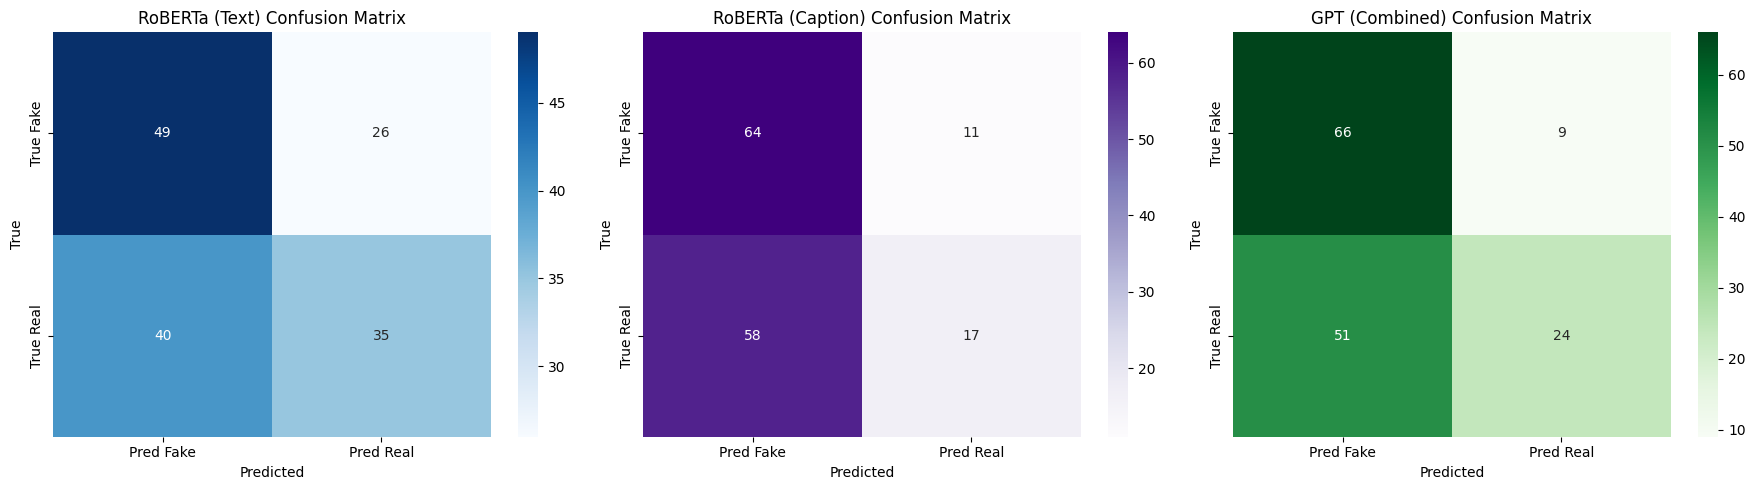

In [ ]:
# Heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(text_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=axes[0])
axes[0].set_title("RoBERTa (Text) Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cap_cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=axes[1])
axes[1].set_title("RoBERTa (Caption) Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

sns.heatmap(llm_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=axes[2])
axes[2].set_title("GPT (Combined) Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")

plt.tight_layout()
plt.show()

In [ ]:
# Classification reports
print("\n-----------------------------------------------------")
print("RoBERTa (Text) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    eval_df["true_label"],
    eval_df["text_label"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("RoBERTa (Caption) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    eval_df["true_label"],
    eval_df["caption_label"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("GPT (Combined) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    eval_df["true_label"],
    eval_df["llm_label"],
    target_names=["Fake", "Real"]
))



-----------------------------------------------------
RoBERTa (Text) Classification Report:
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.55      0.65      0.60        75
        Real       0.57      0.47      0.51        75

    accuracy                           0.56       150
   macro avg       0.56      0.56      0.56       150
weighted avg       0.56      0.56      0.56       150


-----------------------------------------------------
RoBERTa (Caption) Classification Report:
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.52      0.85      0.65        75
        Real       0.61      0.23      0.33        75

    accuracy                           0.54       150
   macro avg       0.57      0.54      0.49       150
weighted avg       0.57      0.54      0.49       150


------------------------------------------------

# Log

In [ ]:
# Show runtime
runtime_sec = T1 - T0
print(f"Total runtime: {runtime_sec/60:.2f} min ({runtime_sec:.1f} sec)")

# Show GPU specs
display(gpu_name, driver_version, vram_total)

Total runtime: 3.99 min (239.4 sec)


'NVIDIA L4'

'550.54.15'

'23034 MiB'

In [ ]:
# Log runtime and gpu specs
log = {
    "pipeline": "Image_to_Text_Fusion_ver1",
    "n_samples": len(image_df),
    "runtime_sec": runtime_sec,
    "gpu_name": gpu_name,
    "driver_version": driver_version,
    "vram_total": vram_total,
}
print(log)

{'pipeline': 'Image_to_Text_Fusion_ver1', 'n_samples': 150, 'runtime_sec': 239.4075561909999, 'gpu_name': 'NVIDIA L4', 'driver_version': '550.54.15', 'vram_total': '23034 MiB'}


# Save

In [ ]:
# Save logs
with open("I2TFv1_runtime_log.jsonl", "a") as f:
    f.write(json.dumps(log) + "\n")

In [ ]:
# Save results_df
results_df.to_csv("I2TFv1_results_df.csv", index=False)

# Save eval_df
eval_df.to_csv("I2TFv1_eval_df.csv", index=False)